## Differential expression dynamics using tradeSeq

0. Define lineage trajectories by CellRank-based probabilities.
1. Compute a common pseudotime scale for mutant and WT.<br>
2. Find DE genes in each lineage between mut vs WT using tradeSeq.

conda activate cellrank

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
import pandas as pd
from anndata import AnnData
import scvelo as scv
import cellrank as cr
import seaborn as sns

import random
random.seed(123)

sc.settings.verbosity = 3

In [2]:
#Sets figure size
from matplotlib import rcParams
rcParams['figure.figsize'] = (5, 5)

## Load raw data and transfer metadata

In [3]:
adata_raw = sc.read('/rds/project/rds-SDzz0CATGms/users/ti283/Preleukemia/analysis/Jak2/Ref_Sample_Merged_lognorm_w_CCscore.h5ad')
integrated_sample = sc.read('/rds/project/rds-SDzz0CATGms/users/ti283/Preleukemia/analysis/Jak2/Integrated_wo_regress_all_projected_LK_only.h5ad')

In [4]:
adata_raw = adata_raw[integrated_sample.obs.index,:]
adata_raw.obs = integrated_sample.obs
adata_raw.uns = integrated_sample.uns

In [5]:
adata = adata_raw.copy()
adata.raw = adata_raw
adata.obsm['X_umap'] = integrated_sample.obsm['X_umap']

In [6]:
adata = adata[adata.obs.Condition!='Jak2_Het'].copy()

In [7]:
Hom_rep1 = sc.read('/rds/project/rds-SDzz0CATGms/users/ti283/Preleukemia/Notebooks/CellRank/Jak2/Integrated_wo_regress_all_projected_LK_only_Jak2_Hom_rep1_w_HSCscore.h5ad')
Hom_rep2 = sc.read('/rds/project/rds-SDzz0CATGms/users/ti283/Preleukemia/Notebooks/CellRank/Jak2/Integrated_wo_regress_all_projected_LK_only_Jak2_Hom_rep2_w_HSCscore.h5ad')
Hom_rep3 = sc.read('/rds/project/rds-SDzz0CATGms/users/ti283/Preleukemia/Notebooks/CellRank/Jak2/Integrated_wo_regress_all_projected_LK_only_Jak2_Hom_rep3_w_HSCscore.h5ad')

WT_rep1 = sc.read('/rds/project/rds-SDzz0CATGms/users/ti283/Preleukemia/Notebooks/CellRank/Jak2/Integrated_wo_regress_all_projected_LK_only_Jak2_WT_rep1_w_HSCscore.h5ad')
WT_rep2 = sc.read('/rds/project/rds-SDzz0CATGms/users/ti283/Preleukemia/Notebooks/CellRank/Jak2/Integrated_wo_regress_all_projected_LK_only_Jak2_WT_rep2_w_HSCscore.h5ad')
WT_rep3 = sc.read('/rds/project/rds-SDzz0CATGms/users/ti283/Preleukemia/Notebooks/CellRank/Jak2/Integrated_wo_regress_all_projected_LK_only_Jak2_WT_rep3_w_HSCscore.h5ad')

In [8]:
adata_w_hscscore = Hom_rep1.concatenate(Hom_rep2, Hom_rep3, WT_rep1, WT_rep2, WT_rep3, index_unique=None)

In [9]:
adata_w_hscscore = adata_w_hscscore[adata.obs.index,:].copy()

In [10]:
adata.obs['HSC_score'] = adata_w_hscscore.obs['HSC_score']

In [11]:
adata = adata[(adata.obs['predicted.id']!='Unassigned'),:].copy()

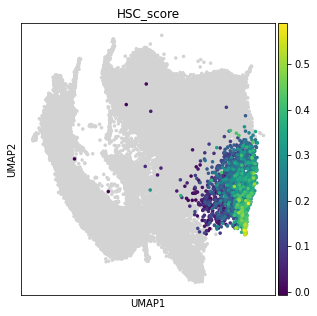

In [12]:
sc.pl.umap(adata,color='HSC_score',s=50)

## Smooth HSC score and compute DPT

In [13]:
hvg = np.genfromtxt('/rds/project/rds-SDzz0CATGms/users/ti283/Preleukemia/analysis/Dahlin_atlas/Ref_Atlas_wo_regress_HVG_5000_rm_CC_genes.txt', dtype=str)
adata = adata[:,hvg]

In [14]:
sc.pp.scale(adata)

/home/ti283/.conda/envs/cellrank/lib/python3.8/site-packages/scanpy/preprocessing/_simple.py:843: UserWarning: Revieved a view of an AnnData. Making a copy.
  view_to_actual(adata)


... as `zero_center=True`, sparse input is densified and may lead to large memory consumption


In [15]:
sc.tl.pca(adata, n_comps=50, svd_solver = 'arpack')

computing PCA
    with n_comps=50
    finished (0:00:35)


In [16]:
sc.pp.neighbors(adata, n_neighbors = 10, n_pcs = 50)

computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:13)


In [17]:
sc.tl.diffmap(adata)

computing Diffusion Maps using n_comps=15(=n_dcs)
computing transitions
    finished (0:00:00)
    eigenvalues of transition matrix
    [1.         0.9980654  0.99522334 0.992746   0.99167943 0.9914071
     0.99109054 0.99019194 0.98817307 0.9855312  0.9847939  0.9837101
     0.98058766 0.97642565 0.97308576]
    finished: added
    'X_diffmap', diffmap coordinates (adata.obsm)
    'diffmap_evals', eigenvalues of transition matrix (adata.uns) (0:00:01)


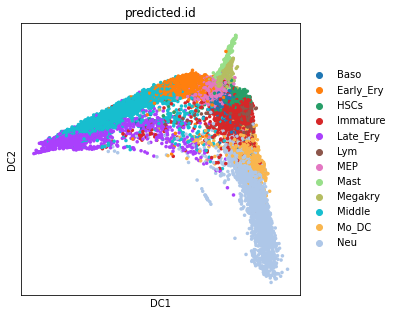

In [18]:
sc.pl.diffmap(adata, color='predicted.id',s=50)

In [19]:
adata_hsc = adata[adata.obs['predicted.id']=='HSCs'].copy()
X_diffmap = adata_hsc.obsm['X_diffmap']

In [20]:
from sklearn.metrics.pairwise import euclidean_distances
D_sub = euclidean_distances(X_diffmap, X_diffmap)
print(D_sub.shape)

(1698, 1698)


In [21]:
knn = D_sub
smoothed = []

for i in range(knn.shape[0]):
    tmp = np.array(knn[i])
    ind = np.argpartition(tmp, 10)[:10] # index for 5 nearest neighbours + itself
    neighbours = adata_hsc.obs.index[ind]
    
    adata_tmp = adata_hsc[neighbours,:].copy()
    
    array_tmp = np.append(adata_tmp.obs['HSC_score'], adata_hsc.obs['HSC_score'][1])
    knn_mean_tmp = array_tmp.mean()
    smoothed.append(knn_mean_tmp)

In [22]:
adata_hsc.obs['HSC_score_smoothed'] = smoothed

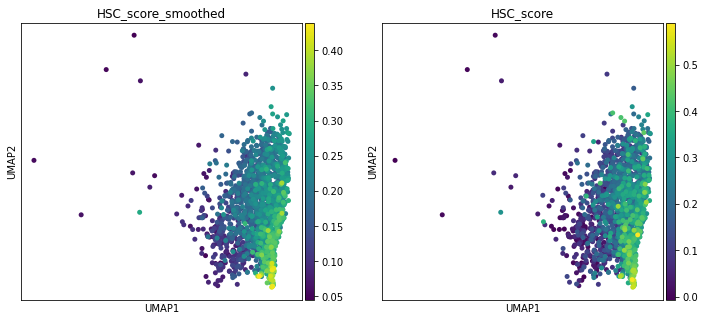

In [23]:
sc.pl.umap(adata_hsc, color=['HSC_score_smoothed','HSC_score'],s=100)

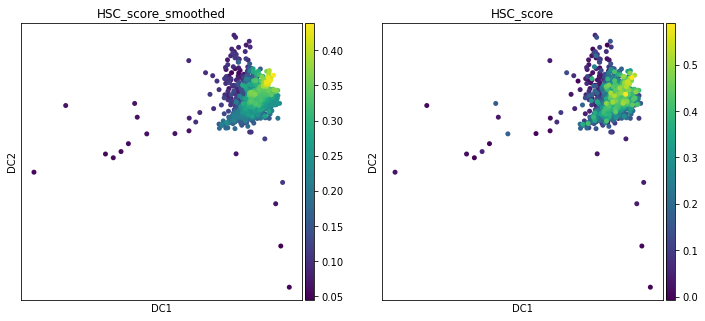

In [24]:
sc.pl.diffmap(adata_hsc, color=['HSC_score_smoothed','HSC_score'],s=100, components=['1,2'])

In [25]:
adata.obs['root_sm'] = 'No'
root_idx = adata_hsc.obs['HSC_score_smoothed'].idxmax()
adata.obs['root_sm']=adata.obs['root_sm'].astype('str')
adata.obs['root_sm'].loc[root_idx] = 'Yes'
adata.obs['root_sm']=adata.obs['root_sm'].astype('category')
adata.uns['root_sm_colors'] = ['#CCCCCC','#b22222']

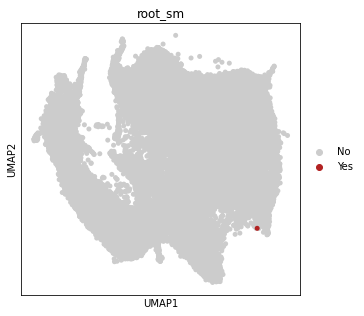

In [26]:
sc.pl.umap(adata[adata.obs.sort_values('root_sm',ascending=True).index], color='root_sm',s=100)

In [27]:
adata.uns['iroot'] = np.flatnonzero(adata.obs['root_sm']  == 'Yes')[0]

In [28]:
sc.tl.dpt(adata)

computing Diffusion Pseudotime using n_dcs=10
    finished: added
    'dpt_pseudotime', the pseudotime (adata.obs) (0:00:00)


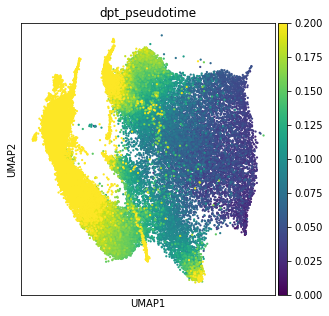

In [29]:
sc.pl.umap(adata, color='dpt_pseudotime',vmax=0.2,s=20)

<AxesSubplot:xlabel='dpt_pseudotime', ylabel='Density'>

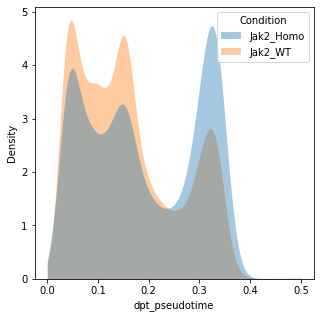

In [30]:
sns.kdeplot(data=adata.obs,#tmp.obs,
            x='dpt_pseudotime',hue='Condition',fill=True,clip=(0,0.5),
            common_norm=False,palette='tab10',alpha=.4,linewidth=0,bw_adjust=1)

In [31]:
df = pd.DataFrame(adata.obs['predicted.id'])
df['dpt_pseudotime'] = adata.obs['dpt_pseudotime']

In [32]:
df

,predicted.id,dpt_pseudotime
AAACCTGAGAGCTGGT-1_SLX11516_SIGAC2,Middle,0.222893
AAACCTGAGCCGGTAA-1_SLX11516_SIGAC2,Late_Ery,0.268090
AAACCTGAGGCAAAGA-1_SLX11516_SIGAC2,Megakry,0.159330
AAACCTGCAATAGCAA-1_SLX11516_SIGAC2,Middle,0.238405
AAACCTGCAATGTTGC-1_SLX11516_SIGAC2,Middle,0.165495
...,...,...
TTTGTCAGTTACCAGT-1_SLX12969_SIGAB8,Late_Ery,0.330536
TTTGTCATCAGAGCTT-1_SLX12969_SIGAB8,Middle,0.323021
TTTGTCATCCCAGGTG-1_SLX12969_SIGAB8,HSCs,0.037987
TTTGTCATCGGCGCAT-1_SLX12969_SIGAB8,Mo_DC,0.126135


In [33]:
df.to_csv('/rds/project/rds-SDzz0CATGms/users/ti283/Preleukemia/Notebooks/CellRank/Jak2/TradeSeq/Homo_WT_combined_DPT.csv')

## Create adata for tradeSeq

Switch to jupyter.mictlan.20e.sif to avoid anndata-Seurat conflict

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
import pandas as pd
from anndata import AnnData
import seaborn as sns

import random
random.seed(123)

sc.settings.verbosity = 3

#Sets figure size
from matplotlib import rcParams
rcParams['figure.figsize'] = (5, 5)

### Read count data and add metadata

In [2]:
adata_count = sc.read('/rds/project/rds-SDzz0CATGms/users/ti283/Preleukemia/analysis/Jak2/Ref_Sample_Merged_raw_count.h5ad')

In [3]:
df = pd.read_csv('/rds/project/rds-SDzz0CATGms/users/ti283/Preleukemia/Notebooks/CellRank/Jak2/TradeSeq/Homo_WT_combined_DPT.csv',index_col=0)

In [4]:
adata_count = adata_count[df.index,:]

2022-10-30 20:57:37,679 [3822192] WARNING  py.warnings:109: [JupyterRequire] /usr/lib/python3.8/site-packages/anndata/_core/anndata.py:1094: FutureWarning: is_categorical is deprecated and will be removed in a future version.  Use is_categorical_dtype instead
  if not is_categorical(df_full[k]):



In [5]:
adata_count.obs['predicted.id'] = df['predicted.id']
adata_count.obs['dpt_pseudotime'] = df['dpt_pseudotime']

Trying to set attribute `.obs` of view, copying.


In [6]:
fate_df = pd.read_csv('/rds/project/rds-SDzz0CATGms/users/ti283/Preleukemia/Notebooks/CellRank/Jak2/TradeSeq/Fate_prob_for_tradeSeq.csv',index_col=0)

In [7]:
fate_df.loc[adata_count.obs.index]

,Ery_prob,Mk_prob,Neu_prob,Mo_prob,Lym_prob
AAACCTGAGAGCTGGT-1_SLX11516_SIGAC2,0.999890,1.327988e-05,1.982990e-05,5.572505e-06,8.362509e-07
AAACCTGAGCCGGTAA-1_SLX11516_SIGAC2,0.999999,5.373335e-08,1.600912e-07,1.289929e-07,5.196226e-09
AAACCTGAGGCAAAGA-1_SLX11516_SIGAC2,0.002376,9.972575e-01,1.220064e-04,1.198268e-04,3.275043e-05
AAACCTGCAATAGCAA-1_SLX11516_SIGAC2,0.999981,2.733940e-06,3.569625e-06,1.131649e-06,1.542888e-07
AAACCTGCAATGTTGC-1_SLX11516_SIGAC2,0.993892,4.076800e-04,7.554831e-04,2.456381e-04,3.827390e-05
...,...,...,...,...,...
TTTGTCAGTTACCAGT-1_SLX12969_SIGAB8,0.999996,8.648610e-07,1.931909e-06,8.187609e-07,4.741551e-08
TTTGTCATCAGAGCTT-1_SLX12969_SIGAB8,0.999982,4.250417e-06,7.516264e-06,3.121170e-06,1.990774e-07
TTTGTCATCCCAGGTG-1_SLX12969_SIGAB8,0.352964,1.223719e-01,1.615568e-01,1.840928e-01,7.515851e-02
TTTGTCATCGGCGCAT-1_SLX12969_SIGAB8,0.024672,1.017234e-03,2.242336e-01,7.431983e-01,1.087269e-03


In [8]:
adata_count.obs['Ery_prob'] = fate_df.loc[adata_count.obs.index]['Ery_prob']
adata_count.obs['Mk_prob'] = fate_df.loc[adata_count.obs.index]['Mk_prob']
adata_count.obs['Neu_prob'] = fate_df.loc[adata_count.obs.index]['Neu_prob']
adata_count.obs['Mo_prob'] = fate_df.loc[adata_count.obs.index]['Mo_prob']

### Cut out each trajectory

In [9]:
thr=0.20
adata_count.obs['Ery_trajectory'] = 'No'
adata_count.obs['Ery_trajectory'] = adata_count.obs['Ery_trajectory'].astype('str')
adata_count.obs['Ery_trajectory'][(adata_count.obs['predicted.id'].isin(['HSCs','Immature','MEP','Early_Ery','Middle ','Late_Ery']))&(adata_count.obs.Ery_prob>=thr)&(adata_count.obs.Neu_prob<0.3)&(adata_count.obs.Mo_prob<0.23)] = 'Yes'
adata_count.obs['Ery_trajectory'] = adata_count.obs['Ery_trajectory'].astype('category')

2022-10-30 20:58:03,063 [3822192] WARNING  py.warnings:109: [JupyterRequire] <ipython-input-9-e2e4952bcc1c>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adata_count.obs['Ery_trajectory'][(adata_count.obs['predicted.id'].isin(['HSCs','Immature','MEP','Early_Ery','Middle ','Late_Ery']))&(adata_count.obs.Ery_prob>=thr)&(adata_count.obs.Neu_prob<0.3)&(adata_count.obs.Mo_prob<0.23)] = 'Yes'



In [10]:
thr=0.12
adata_count.obs['Mk_trajectory'] = 'No'
adata_count.obs['Mk_trajectory'] = adata_count.obs['Mk_trajectory'].astype('str')
adata_count.obs['Mk_trajectory'][(adata_count.obs['predicted.id'].isin(['HSCs','Immature','MEP','Megakry']))&(adata_count.obs.Mk_prob>=thr)] = 'Yes'
adata_count.obs['Mk_trajectory'] = adata_count.obs['Mk_trajectory'].astype('category')

2022-10-30 20:58:11,779 [3822192] WARNING  py.warnings:109: [JupyterRequire] <ipython-input-10-cde3095c0508>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adata_count.obs['Mk_trajectory'][(adata_count.obs['predicted.id'].isin(['HSCs','Immature','MEP','Megakry']))&(adata_count.obs.Mk_prob>=thr)] = 'Yes'



In [11]:
thr=0.12
adata_count.obs['Neu_trajectory'] = 'No'
adata_count.obs['Neu_trajectory'] = adata_count.obs['Neu_trajectory'].astype('str')
adata_count.obs['Neu_trajectory'][(adata_count.obs['predicted.id'].isin(['HSCs','Immature','Neu']))&(adata_count.obs.Neu_prob>=thr)] = 'Yes'
adata_count.obs['Neu_trajectory'] = adata_count.obs['Neu_trajectory'].astype('category')

2022-10-30 20:58:11,842 [3822192] WARNING  py.warnings:109: [JupyterRequire] <ipython-input-11-d3e7a0618e69>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adata_count.obs['Neu_trajectory'][(adata_count.obs['predicted.id'].isin(['HSCs','Immature','Neu']))&(adata_count.obs.Neu_prob>=thr)] = 'Yes'



In [12]:
thr=0.10
adata_count.obs['Mo_trajectory'] = 'No'
adata_count.obs['Mo_trajectory'] = adata_count.obs['Mo_trajectory'].astype('str')
adata_count.obs['Mo_trajectory'][(adata_count.obs['predicted.id'].isin(['HSCs','Immature','Mo_DC']))&(adata_count.obs.Mo_prob>=thr)] = 'Yes'
adata_count.obs['Mo_trajectory'] = adata_count.obs['Mo_trajectory'].astype('category')

2022-10-30 20:58:11,887 [3822192] WARNING  py.warnings:109: [JupyterRequire] <ipython-input-12-f05e8a1aa7b2>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adata_count.obs['Mo_trajectory'][(adata_count.obs['predicted.id'].isin(['HSCs','Immature','Mo_DC']))&(adata_count.obs.Mo_prob>=thr)] = 'Yes'



In [13]:
adata_count_Ery = adata_count[adata_count.obs.Ery_trajectory=='Yes']
adata_count_Mk = adata_count[adata_count.obs.Mk_trajectory=='Yes']
adata_count_Neu = adata_count[adata_count.obs.Neu_trajectory=='Yes']
adata_count_Mo = adata_count[adata_count.obs.Mo_trajectory=='Yes']

2022-10-30 20:58:11,938 [3822192] WARNING  py.warnings:109: [JupyterRequire] /usr/lib/python3.8/site-packages/anndata/_core/anndata.py:1094: FutureWarning: is_categorical is deprecated and will be removed in a future version.  Use is_categorical_dtype instead
  if not is_categorical(df_full[k]):



### Check pseudotime distribution

<AxesSubplot:xlabel='dpt_pseudotime', ylabel='Density'>

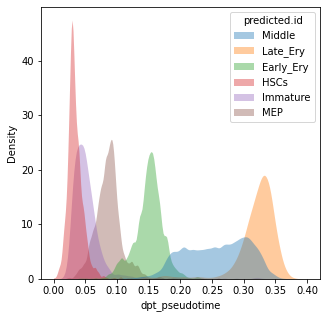

In [14]:
sns.kdeplot(data=adata_count_Ery.obs,
            x='dpt_pseudotime',hue='predicted.id',fill=True, clip= (0.0, 0.4),
            common_norm=False,palette='tab10',alpha=.4,linewidth=0,bw_adjust=.5)

<AxesSubplot:xlabel='dpt_pseudotime', ylabel='Density'>

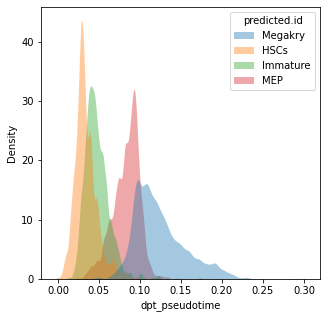

In [15]:
sns.kdeplot(data=adata_count_Mk.obs,
            x='dpt_pseudotime',hue='predicted.id',fill=True, #clip= (0.0, 0.4),
            common_norm=False,palette='tab10',alpha=.4,linewidth=0,bw_adjust=.5)

<AxesSubplot:xlabel='dpt_pseudotime', ylabel='Density'>

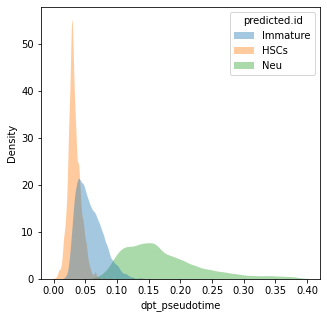

In [16]:
sns.kdeplot(data=adata_count_Neu.obs,
            x='dpt_pseudotime',hue='predicted.id',fill=True, clip= (0.0, 0.4),
            common_norm=False,palette='tab10',alpha=.4,linewidth=0,bw_adjust=.5)

<AxesSubplot:xlabel='dpt_pseudotime', ylabel='Density'>

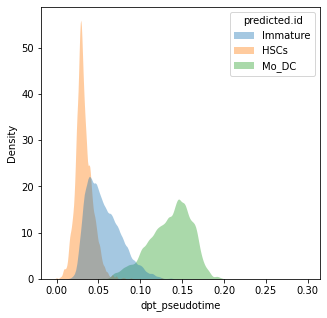

In [17]:
sns.kdeplot(data=adata_count_Mo.obs,
            x='dpt_pseudotime',hue='predicted.id',fill=True, #clip= (0.0, 0.4),
            common_norm=False,palette='tab10',alpha=.4,linewidth=0,bw_adjust=.5)

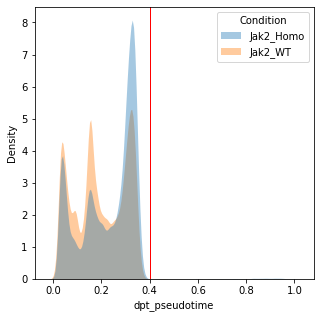

In [18]:
sns.kdeplot(data=adata_count_Ery.obs,
            x='dpt_pseudotime',hue='Condition',fill=True, #clip= (0.0, 0.4),
            common_norm=False,palette='tab10',alpha=.4,linewidth=0,bw_adjust=.5)
plt.axvline(0.4, color='r', linestyle='solid', linewidth=1)

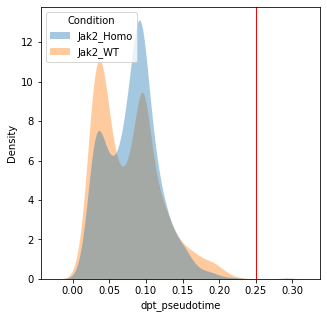

In [19]:
sns.kdeplot(data=adata_count_Mk.obs,
            x='dpt_pseudotime',hue='Condition',fill=True, #clip= (0.0, 0.25),
            common_norm=False,palette='tab10',alpha=.4,linewidth=0,bw_adjust=1)
plt.axvline(0.25, color='r', linestyle='solid', linewidth=1)

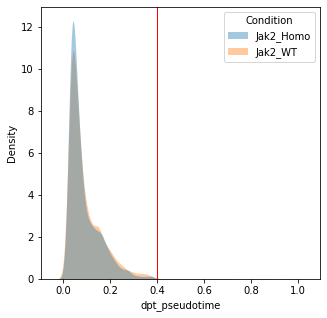

In [20]:
sns.kdeplot(data=adata_count_Neu.obs,
            x='dpt_pseudotime',hue='Condition',fill=True,
            common_norm=False,palette='tab10',alpha=.4,linewidth=0,bw_adjust=1)
plt.axvline(0.4, color='r', linestyle='solid', linewidth=1)

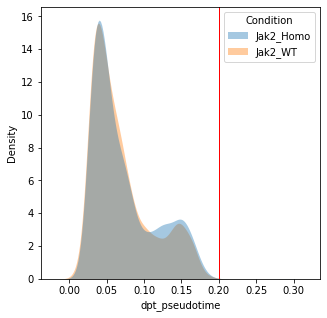

In [21]:
sns.kdeplot(data=adata_count_Mo.obs,
            x='dpt_pseudotime',hue='Condition',fill=True,
            common_norm=False,palette='tab10',alpha=.4,linewidth=0,bw_adjust=1)
plt.axvline(0.2, color='r', linestyle='solid', linewidth=1)

### Remove pseudotime outliers

In [22]:
adata_count_Ery = adata_count_Ery[adata_count_Ery.obs.dpt_pseudotime <0.4]
adata_count_Mk = adata_count_Mk[adata_count_Mk.obs.dpt_pseudotime <0.25]
adata_count_Neu = adata_count_Neu[adata_count_Neu.obs.dpt_pseudotime <0.4]
adata_count_Mo = adata_count_Mo[adata_count_Mo.obs.dpt_pseudotime <0.2]

2022-10-30 20:58:35,436 [3822192] WARNING  py.warnings:109: [JupyterRequire] /usr/lib/python3.8/site-packages/anndata/_core/anndata.py:1094: FutureWarning: is_categorical is deprecated and will be removed in a future version.  Use is_categorical_dtype instead
  if not is_categorical(df_full[k]):

2022-10-30 20:58:35,444 [3822192] WARNING  py.warnings:109: [JupyterRequire] /usr/lib/python3.8/site-packages/anndata/_core/anndata.py:1094: FutureWarning: is_categorical is deprecated and will be removed in a future version.  Use is_categorical_dtype instead
  if not is_categorical(df_full[k]):

2022-10-30 20:58:35,450 [3822192] WARNING  py.warnings:109: [JupyterRequire] /usr/lib/python3.8/site-packages/anndata/_core/anndata.py:1094: FutureWarning: is_categorical is deprecated and will be removed in a future version.  Use is_categorical_dtype instead
  if not is_categorical(df_full[k]):

2022-10-30 20:58:35,457 [3822192] WARNING  py.warnings:109: [JupyterRequire] /usr/lib/python3.8/site-packa

### Remove low-expression genes

In [23]:
# Remove unexpressed genes
sc.pp.filter_genes(adata_count_Ery, min_cells = 1)
sc.pp.filter_genes(adata_count_Mk, min_cells = 1)
sc.pp.filter_genes(adata_count_Neu, min_cells = 1)
sc.pp.filter_genes(adata_count_Mo, min_cells = 1)

filtered out 2471 genes that are detected in less than 1 cells


Trying to set attribute `.var` of view, copying.


filtered out 4694 genes that are detected in less than 1 cells


Trying to set attribute `.var` of view, copying.


filtered out 3249 genes that are detected in less than 1 cells


Trying to set attribute `.var` of view, copying.


filtered out 3477 genes that are detected in less than 1 cells


Trying to set attribute `.var` of view, copying.


In [24]:
# CP10K normalisation
adata_count_Ery_tmp = sc.pp.normalize_per_cell(adata_count_Ery, counts_per_cell_after = 10000,copy=True)
adata_count_Mk_tmp = sc.pp.normalize_per_cell(adata_count_Mk, counts_per_cell_after = 10000,copy=True)
adata_count_Neu_tmp = sc.pp.normalize_per_cell(adata_count_Neu, counts_per_cell_after = 10000,copy=True)
adata_count_Mo_tmp = sc.pp.normalize_per_cell(adata_count_Mo, counts_per_cell_after = 10000,copy=True)

normalizing by total count per cell
    finished (0:00:00): normalized adata.X and added    'n_counts', counts per cell before normalization (adata.obs)
normalizing by total count per cell


2022-10-30 20:58:52,804 [3822192] WARNING  py.warnings:109: [JupyterRequire] /usr/lib/python3.8/site-packages/anndata/_core/anndata.py:1094: FutureWarning: is_categorical is deprecated and will be removed in a future version.  Use is_categorical_dtype instead
  if not is_categorical(df_full[k]):



    finished (0:00:00): normalized adata.X and added    'n_counts', counts per cell before normalization (adata.obs)
normalizing by total count per cell


2022-10-30 20:58:52,993 [3822192] WARNING  py.warnings:109: [JupyterRequire] /usr/lib/python3.8/site-packages/anndata/_core/anndata.py:1094: FutureWarning: is_categorical is deprecated and will be removed in a future version.  Use is_categorical_dtype instead
  if not is_categorical(df_full[k]):



    finished (0:00:00): normalized adata.X and added    'n_counts', counts per cell before normalization (adata.obs)
normalizing by total count per cell


2022-10-30 20:58:53,378 [3822192] WARNING  py.warnings:109: [JupyterRequire] /usr/lib/python3.8/site-packages/anndata/_core/anndata.py:1094: FutureWarning: is_categorical is deprecated and will be removed in a future version.  Use is_categorical_dtype instead
  if not is_categorical(df_full[k]):



    finished (0:00:00): normalized adata.X and added    'n_counts', counts per cell before normalization (adata.obs)


In [25]:
meanExp_Ery = np.mean(adata_count_Ery_tmp.X.todense(), axis=0)
meanExp_Mk = np.mean(adata_count_Mk_tmp.X.todense(), axis=0)
meanExp_Neu = np.mean(adata_count_Neu_tmp.X.todense(), axis=0)
meanExp_Mo = np.mean(adata_count_Mo_tmp.X.todense(), axis=0)

In [26]:
# Remove low-expression genes with CP10K ≤ 0.05
adata_count_Ery_tmp = adata_count_Ery_tmp[:,meanExp_Ery>0.05]
adata_count_Mk_tmp = adata_count_Mk_tmp[:,meanExp_Mk>0.05]
adata_count_Neu_tmp = adata_count_Neu_tmp[:,meanExp_Neu>0.05]
adata_count_Mo_tmp = adata_count_Mo_tmp[:,meanExp_Mo>0.05]

2022-10-30 20:58:55,519 [3822192] WARNING  py.warnings:109: [JupyterRequire] /usr/lib/python3.8/site-packages/anndata/_core/anndata.py:1094: FutureWarning: is_categorical is deprecated and will be removed in a future version.  Use is_categorical_dtype instead
  if not is_categorical(df_full[k]):



In [27]:
adata_count_Ery = adata_count_Ery[:,adata_count_Ery_tmp.var.index]
adata_count_Mk = adata_count_Mk[:,adata_count_Mk_tmp.var.index]
adata_count_Neu = adata_count_Neu[:,adata_count_Neu_tmp.var.index]
adata_count_Mo = adata_count_Mo[:,adata_count_Mo_tmp.var.index]

In [28]:
adata_count_Ery.write('/rds/project/rds-SDzz0CATGms/users/ti283/Preleukemia/Notebooks/CellRank/Jak2/TradeSeq/Homo_WT_count_Ery.h5ad')
adata_count_Mk.write('/rds/project/rds-SDzz0CATGms/users/ti283/Preleukemia/Notebooks/CellRank/Jak2/TradeSeq/Homo_WT_count_Mk.h5ad')
adata_count_Neu.write('/rds/project/rds-SDzz0CATGms/users/ti283/Preleukemia/Notebooks/CellRank/Jak2/TradeSeq/Homo_WT_count_Neu.h5ad')
adata_count_Mo.write('/rds/project/rds-SDzz0CATGms/users/ti283/Preleukemia/Notebooks/CellRank/Jak2/TradeSeq/Homo_WT_count_Mo.h5ad')

2022-10-30 20:58:55,590 [3822192] WARNING  py.warnings:109: [JupyterRequire] /usr/lib/python3.8/site-packages/anndata/_core/anndata.py:1192: FutureWarning: is_categorical is deprecated and will be removed in a future version.  Use is_categorical_dtype instead
  if is_string_dtype(df[key]) and not is_categorical(df[key])

2022-10-30 20:58:55,606 [3822192] WARNING  py.warnings:109: [JupyterRequire] /usr/lib/python3.8/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning: Initializing view as actual.
  warnings.warn(

Trying to set attribute `.obs` of view, copying.
... storing 'predicted.id' as categorical
Trying to set attribute `.obs` of view, copying.
... storing 'predicted.id' as categorical
Trying to set attribute `.obs` of view, copying.
... storing 'predicted.id' as categorical
Trying to set attribute `.obs` of view, copying.
... storing 'predicted.id' as categorical


## TradeSeq for each lineage

In [ ]:
# From terminal, using singularity 25h
# Start R

library(SingleCellExperiment)
library(zellkonverter)
library(tradeSeq)

###############################################
sce <- readH5AD("/rds/project/rds-SDzz0CATGms/users/ti283/Preleukemia/Notebooks/CellRank/Jak2/TradeSeq/Homo_WT_count_Ery.h5ad")

###############################################
table(colData(sce)$predicted.id)
table(colData(sce)$dataset)

###############################################
# set all cell weights to 1
cw <- rep(1,ncol(sce))

###############################################
# pseudotime
pseudotime <- colData(sce)$dpt_pseudotime 

###############################################
# create a model matrix
batch <- as.factor(colData(sce)$dataset)
U <- model.matrix(~batch)

###############################################
# Fit GAM using tradeSeq
set.seed(5)
sceGAM <- fitGAM(counts = as.matrix(assays(sce)$X),
                 conditions = factor(colData(sce)$Condition),
                 U = U,
                 pseudotime=pseudotime,
                 cellWeights=cw,
                 nknots=6,
                 BPPARAM=MulticoreParam(workers=20),
                 verbose=T)

#saveRDS(sceGAM,
#        file="/rds/project/rds-SDzz0CATGms/users/ti283/Preleukemia/Notebooks/CellRank/Jak2/TradeSeq/Jak2_Ery_sceGAM.rds")

#sceGAM = readRDS("/rds/project/rds-SDzz0CATGms/users/ti283/Preleukemia/Notebooks/CellRank/Jak2/TradeSeq/Jak2_Ery_sceGAM.rds")

###############################################
# Differential expression between conditions
condRes <- conditionTest(sceGAM, l2fc = 0.5)
condRes$padj <- p.adjust(condRes$pvalue, "fdr")
write.table(condRes,"/rds/project/rds-SDzz0CATGms/users/ti283/Preleukemia/Notebooks/CellRank/Jak2/TradeSeq/Jak2_conditionTest_Ery_lfc0.5.txt",
            sep='\t',quote=F,row.names=T)

###############################################
# plot smoothers
#gene_to_plot = "Sapcd1"

res = read.delim("/rds/project/rds-SDzz0CATGms/users/ti283/Preleukemia/Notebooks/CellRank/Jak2/TradeSeq/Jak2_conditionTest_Ery_lfc0.5_sorted.txt",
                row.names=1)
gene.ls = as.character(rownames(res)[which(res$padj<0.05)])

for (gene_to_plot in gene.ls) {
    pdf(paste0("/rds/project/rds-SDzz0CATGms/users/ti283/Preleukemia/Notebooks/CellRank/Jak2/TradeSeq/SmoothPlots/white/Jak2_Ery_",gene_to_plot,".pdf"))
    print(plotSmoothers(sceGAM, as.matrix(assays(sce)$X), gene_to_plot) + ggplot2::ggtitle(gene_to_plot) +
    ggplot2::scale_colour_manual(values = c("white","white")))
    print(plotSmoothers(sceGAM, as.matrix(assays(sce)$X), gene_to_plot) + ggplot2::facet_wrap(~lineage)+
    ggplot2::ggtitle(gene_to_plot)+ggplot2::scale_colour_manual(values = c("white","white")))
    dev.off()
    
    pdf(paste0("/rds/project/rds-SDzz0CATGms/users/ti283/Preleukemia/Notebooks/CellRank/Jak2/TradeSeq/SmoothPlots/default/Jak2_Ery_",gene_to_plot,".pdf"))
    print(plotSmoothers(sceGAM, as.matrix(assays(sce)$X), gene_to_plot) + ggplot2::ggtitle(gene_to_plot))
    print(plotSmoothers(sceGAM, as.matrix(assays(sce)$X), gene_to_plot) + ggplot2::facet_wrap(~lineage)+
    ggplot2::ggtitle(gene_to_plot))
    dev.off()
}


## Plot pseudotime & trajectory for Fig

In [29]:
adata_count_Ery = sc.read('/rds/project/rds-SDzz0CATGms/users/ti283/Preleukemia/Notebooks/CellRank/Jak2/TradeSeq/Homo_WT_count_Ery.h5ad')

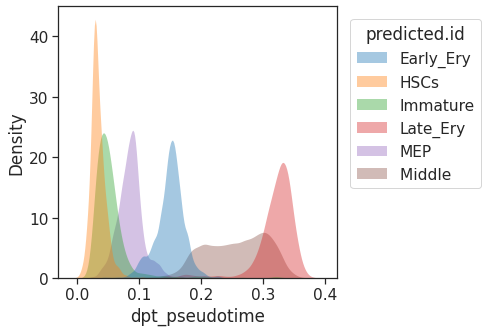

In [30]:
sns.set(font_scale=1.4,style='ticks')
ax = sns.kdeplot(data=adata_count_Ery.obs,
            x='dpt_pseudotime',hue='predicted.id',fill=True, #clip= (0.0, 0.4),
            common_norm=False,palette='tab10',alpha=.4,linewidth=0,bw_adjust=.8)
ax.legend_.set_bbox_to_anchor((1.02, 0.98))
ax.legend_._set_loc(2)
plt.show()

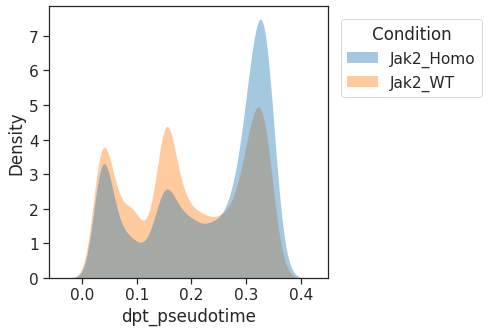

In [31]:
sns.set(font_scale=1.4,style='ticks')
ax = sns.kdeplot(data=adata_count_Ery.obs,
            x='dpt_pseudotime',hue='Condition',fill=True, #clip= (0.0, 0.4),
            common_norm=False,palette='tab10',alpha=.4,linewidth=0,bw_adjust=.8)
ax.legend_.set_bbox_to_anchor((1.02, 0.98))
ax.legend_._set_loc(2)
plt.show()

In [32]:
integrated = sc.read('/rds/project/rds-SDzz0CATGms/users/ti283/Preleukemia/analysis/Jak2/Integrated_wo_regress_all_projected_LK_only.h5ad')
integrated = integrated[integrated.obs.Condition!='Jak2_Het',:].copy()

2022-10-30 20:59:37,452 [3822192] WARNING  py.warnings:109: [JupyterRequire] /usr/lib/python3.8/site-packages/anndata/_core/anndata.py:1094: FutureWarning: is_categorical is deprecated and will be removed in a future version.  Use is_categorical_dtype instead
  if not is_categorical(df_full[k]):



In [33]:
fate_df = pd.read_csv('/rds/project/rds-SDzz0CATGms/users/ti283/Preleukemia/Notebooks/CellRank/Jak2/TradeSeq/Fate_prob_for_tradeSeq.csv',index_col=0)
integrated = integrated[fate_df.index,:].copy()

In [34]:
thr=0.20

integrated.obs['Ery_prob'] = fate_df.loc[integrated.obs.index]['Ery_prob']
integrated.obs['Neu_prob'] = fate_df.loc[integrated.obs.index]['Neu_prob']
integrated.obs['Mo_prob'] = fate_df.loc[integrated.obs.index]['Mo_prob']

integrated.obs['Ery_trajectory'] = 'No'
integrated.obs['Ery_trajectory'] = integrated.obs['Ery_trajectory'].astype('str')
integrated.obs['Ery_trajectory'][(integrated.obs['predicted.id'].isin(['HSCs','Immature','MEP','Early_Ery','Middle ','Late_Ery']))&(integrated.obs.Ery_prob>=thr)&(integrated.obs.Neu_prob<0.3)&(integrated.obs.Mo_prob<0.23)] = 'Yes'
integrated.obs['Ery_trajectory'] = integrated.obs['Ery_trajectory'].astype('category')

2022-10-30 21:00:13,445 [3822192] WARNING  py.warnings:109: [JupyterRequire] <ipython-input-34-cf956ac74cc9>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  integrated.obs['Ery_trajectory'][(integrated.obs['predicted.id'].isin(['HSCs','Immature','MEP','Early_Ery','Middle ','Late_Ery']))&(integrated.obs.Ery_prob>=thr)&(integrated.obs.Neu_prob<0.3)&(integrated.obs.Mo_prob<0.23)] = 'Yes'



In [35]:
integrated.uns['Ery_trajectory_colors']=['#CCCCCC','#b22222']

2022-10-30 21:00:17,043 [3822192] WARNING  py.warnings:109: [JupyterRequire] /usr/lib/python3.8/site-packages/anndata/_core/anndata.py:1192: FutureWarning: is_categorical is deprecated and will be removed in a future version.  Use is_categorical_dtype instead
  if is_string_dtype(df[key]) and not is_categorical(df[key])



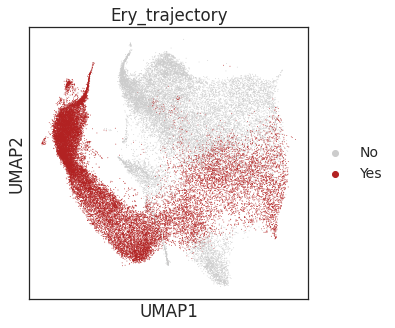

In [36]:
sc.pl.umap(integrated,color = 'Ery_trajectory',legend_fontsize=14)

## Check expression manually

In [ ]:
integrated = sc.read('/rds/project/rds-SDzz0CATGms/users/ti283/Preleukemia/analysis/Jak2/Integrated_wo_regress_all_projected_LK_only.h5ad')

In [ ]:
integrated = integrated[integrated.obs.Condition!='Jak2_Het',:].copy()

In [ ]:
gene = 'Hba-a1'

nrow = 1
ncol = 2
fig, ax = plt.subplots(nrow,ncol, figsize=(10,5), sharex=True, sharey=True)
Condition_unique = integrated.obs['Condition'].cat.categories
for i in range(len(Condition_unique)):
    colidx = i%ncol
    #rowidx = np.floor(i/ncol).astype(int)
    ax1 = sc.pl.umap(integrated[integrated.obs['Condition'] == Condition_unique[i]], 
                     title=Condition_unique[i], color=gene,ax=ax[colidx], 
                     show=False, s=20)
    #ax1.get_legend().remove()
plt.tight_layout() 

In [ ]:
df = pd.read_csv('/rds/project/rds-SDzz0CATGms/users/ti283/Preleukemia/Notebooks/CellRank/Jak2/TradeSeq/Homo_WT_combined_DPT.csv',index_col=0)
integrated = integrated[df.index,:]
integrated.obs['dpt_pseudotime'] = df['dpt_pseudotime']

In [ ]:
sc.pl.umap(integrated, color='dpt_pseudotime', vmax=0.4, vmin=0.25)